#### TODO:
* redo everything including 'Declared clinically ready for discharge'=='No' (only did isna() here). And check for duplicate eids in final_cohort. (Also only include first ICU stay?) 
* split features into raw and t-series (impute as raw, and fillna -1 or 0 for t-series?)
* hypertuning
* add demographic parameters (and string params e.g. ett)
* check feature importance
* (add time series features - covariance? And feature interactions?)
* add feature selection using mlxtend SFS
* trial new sampling/training regime
* include non rfd patients
* improve class size balancing so that we retain all NRFD instances for patients who were declared fit for discharge but had a negative outcome - these are the harder cases, and they are currently being diluted by the other NRFD instances (from earlier in stays).

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.pipeline import Pipeline
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
%matplotlib inline

In [2]:
FILLNA = False
FILLNA_VAL = 0

In [3]:
project_name = 'smartt_bmj_open_plus'

In [4]:
save_to_path = Path(f"E:/SMARTT/data/processed/{project_name}")

In [5]:
final_cohort = pd.read_json('..\data\processed\linked_cohort_181024.json', convert_dates=['admitStoreDateTime', 'dischargeStoreDateTime', 'rfd_datetime'])

In [6]:
(final_cohort['dischargeStoreDateTime'] - final_cohort['admitStoreDateTime']).median()

Timedelta('3 days 17:31:07.024000')

In [7]:
all_samples = pd.read_csv(save_to_path / f"all_24hr_samples_final_cohort_.csv", low_memory=False)

In [8]:
all_high_freq_samples = pd.read_csv(save_to_path / f"all_4hr_samples_from_12_hours_final_cohort_.csv", low_memory=False)

In [9]:
original_features = [
    'Glasgow Coma Scale_ffill', 'temperature_ffill', 'arterial blood pressure (mean)_ffill', 'Fio2_ffill',
    'arterial oxygen saturation_ffill', 'respiratory rate_ffill', 'Heart rate_ffill', 'actual bicarbonate_ffill',
    'Hemoglobin_ffill', 'platelet count_ffill', 'Sodium_ffill', 'potassium_ffill',
    'creatinine_ffill', 'urea_ffill', 'Bilirubin_ffill', 'positive end-expiratory pressure_ffill', 'hours_since_admission'
]

In [10]:
new_features = [
    c
    for c in all_samples.columns
    if '_ffill' in c and c not in original_features and 'trach' not in c and 'delta' not in c
]

In [12]:
temporal_features = [
    c
    for c in all_samples.columns
    if 'delta' in c
]

In [13]:
all_features = original_features + new_features + temporal_features

In [14]:
all_samples['label'] = [s in ['True', '1', 1] for s in all_samples['label']]

In [15]:
for f in all_samples[original_features + ['hours_since_admission', 'eid'] + new_features + temporal_features]:
    all_samples[f] = pd.to_numeric(all_samples[f], errors='coerce')

In [16]:
 all_samples = all_samples[
     ['time', 'hours_since_admission', 'label', 'eid']
     + all_features
]
# ].dropna()

In [17]:
NNeigh = 5
imputer = KNNImputer(n_neighbors=NNeigh)

In [18]:
impute_features = original_features + new_features
all_samples.loc[:,impute_features] = imputer.fit_transform(all_samples[impute_features])

In [19]:
if FILLNA:
    all_samples.loc[:,temporal_features] = all_samples[temporal_features].fillna(FILLNA_VAL, inplace=False)

In [20]:
all_samples.groupby('label').count()

,time,hours_since_admission,eid,Glasgow Coma Scale_ffill,temperature_ffill,arterial blood pressure (mean)_ffill,Fio2_ffill,arterial oxygen saturation_ffill,respiratory rate_ffill,Heart rate_ffill,...,creatinine_ffill_delta_3,urea_ffill_delta_1,urea_ffill_delta_2,urea_ffill_delta_3,Bilirubin_ffill_delta_1,Bilirubin_ffill_delta_2,Bilirubin_ffill_delta_3,positive end-expiratory pressure_ffill_delta_1,positive end-expiratory pressure_ffill_delta_2,positive end-expiratory pressure_ffill_delta_3
label,,,,,,,,,,,,,,,,,,,,,
False,16796,16807,16796,16807,16807,16807,16807,16807,16807,16807,...,5935,16627,5946,5946,13644,5163,4829,14062,4055,4055
True,4129,4129,4129,4129,4129,4129,4129,4129,4129,4129,...,1444,3598,1446,1446,2978,1215,1160,1787,650,650


In [21]:
scaler = StandardScaler()

In [22]:
scaled_samples = all_samples.copy()
# scaled_samples[original_features] = scaler.fit_transform(scaled_samples[original_features])
scaled_samples[all_features] = scaler.fit_transform(scaled_samples[all_features])

In [23]:
desired_class_size = len(scaled_samples[scaled_samples.label==1])

In [24]:
scaled_samples = pd.concat([
    scaled_samples[scaled_samples.label==1],
    scaled_samples[scaled_samples.label==0].sample(n=desired_class_size)
])

In [735]:
train, test = train_test_split(final_cohort[final_cohort['Declared clinically ready for discharge']=='Yes'], test_size=0.2, random_state=42)

In [736]:
# train, test = train_test_split(scaled_samples, test_size=0.2)
train = scaled_samples[scaled_samples.eid.isin(train.encounterId)]
test = scaled_samples[scaled_samples.eid.isin(test.encounterId)]

In [737]:
lr_features = original_features + new_features
rf_features = original_features + new_features
nrf_features = all_features

In [28]:
rf_grid_space ={
    'max_depth': [3, 5, 10, None],
    'n_estimators': [10, 100, 200],
    'max_features': [3, 5, 7, 'sqrt', None],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 3, 5],
}

In [29]:
# clf = RandomForestClassifier(random_state=0).fit(
#     train[original_features],
#     train['label'],
# )
clf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=rf_grid_space, cv=5, scoring='accuracy', verbose=2, n_jobs=-1).fit(
    train[rf_features],
    train['label'],
)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


In [30]:
clf.score(
    test[rf_features],
    test['label']
)

0.8011904761904762

In [31]:
# nclf = RandomForestClassifier(random_state=0).fit(
#     train[original_features + new_features],
#     train['label'],
# )
nclf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=rf_grid_space, cv=5, scoring='accuracy', verbose=2, n_jobs=-1).fit(
    train[nrf_features],
    train['label'],
)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


C:\Users\mcwilliamschr\Documents\SMARTT\sniffer_release\SMARTTDataExtraction\newenv\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [32]:
nclf.score(
    test[nrf_features],
    test['label']
)

0.8380952380952381

In [33]:
lr_clf = LogisticRegression(random_state=0).fit(
    train[lr_features],
    train['label'],
)

In [34]:
lr_clf.score(
    test[lr_features],
    test['label']
)

0.7875

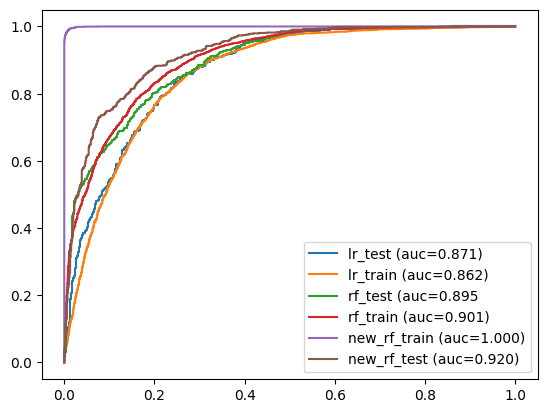

In [745]:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_test (auc={auc:.3f})")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    lr_clf.predict_proba(train[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    lr_clf.predict_proba(train[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_train (auc={auc:.3f})")

## RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_test (auc={auc:.3f}")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    clf.predict_proba(train[rf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    clf.predict_proba(train[rf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_train (auc={auc:.3f})")


## New RF:
fpr, tpr, thresholds = roc_curve(
    train['label'],
    nclf.predict_proba(train[nrf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    nclf.predict_proba(train[nrf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_train (auc={auc:.3f})")


fpr, tpr, thresholds = roc_curve(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_test (auc={auc:.3f})")



plt.legend();

In [739]:
thresh = [t for t in thresholds if t > 0.5][-1]#.index(0.50052882)

In [740]:
tpr[list(thresholds).index(thresh)]

np.float64(0.8626506024096385)

In [741]:
fpr[list(thresholds).index(thresh)]

np.float64(0.18588235294117647)

In [742]:
from sklearn.metrics import confusion_matrix, f1_score

In [743]:
alpha = 0.5
# y_pred = nclf.predict_proba(test[nrf_features])[:,1] >= alpha
# y_pred = lr_clf.predict_proba(test[lr_features])[:,1] >= alpha
y_pred = clf.predict_proba(test[rf_features])[:,1] >= alpha
y_true = test.label

In [744]:
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
f1 = f1_score(y_true, y_pred)
print(f"Sensitivity: {tp/(tp+fn):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}")
print(f"Accuracy: {(tp+tn)/(tp+tn+fp+fn):.3f}")
print(f"F1: {f1:.3f}")

Sensitivity: 0.813
Specificity: 0.789
Accuracy: 0.801
F1: 0.802


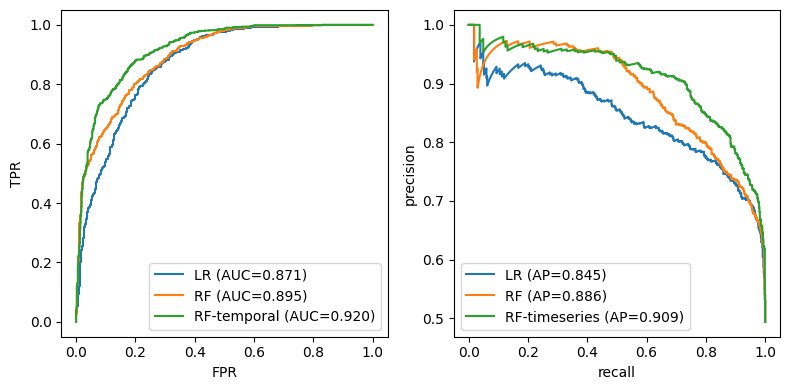

In [746]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
fpr, tpr, thresholds = roc_curve(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"LR (AUC={auc:.3f})")

## RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"RF (AUC={auc:.3f})")

## New RF:
# fpr, tpr, thresholds = roc_curve(
#     test['label'],
#     rfc2.predict_proba(test[selected_features])[:,1],
#     pos_label=1
# )
# auc = roc_auc_score(
#     test['label'],
#     rfc2.predict_proba(test[selected_features])[:,1]
# )
fpr, tpr, thresholds = roc_curve(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"RF-temporal (AUC={auc:.3f})")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend();
################# PRC
plt.subplot(1,2,2)
precision, recall, thresholds = precision_recall_curve(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = average_precision_score(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1]
)
plt.plot(recall, precision, label=f"LR (AP={auc:.3f})")

## RF:
precision, recall, thresholds = precision_recall_curve(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1],
    pos_label=1
)
auc = average_precision_score(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1]
)
plt.plot(recall, precision, label=f"RF (AP={auc:.3f})")

## New RF:
# precision, recall, thresholds = precision_recall_curve(
#     test['label'],
#     rfc2.predict_proba(test[selected_features])[:,1],
#     pos_label=1
# )
# auc = average_precision_score(
#     test['label'],
#     rfc2.predict_proba(test[selected_features])[:,1]
# )
precision, recall, thresholds = precision_recall_curve(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1],
    pos_label=1
)
auc = average_precision_score(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1]
)
plt.plot(recall, precision, label=f"RF-timeseries (AP={auc:.3f})")
plt.xlabel('recall')
plt.ylabel('precision')
plt.legend();
plt.tight_layout()

In [752]:
precision[::-1][768]

np.float64(0.8480204342273308)

In [750]:
[i for i,z in enumerate(recall[::-1]) if z>=0.8][0]

768

In [73]:
len(all_features)

76

In [74]:
nclf.best_params_

{'max_depth': None,
 'max_features': 5,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 100}

In [42]:
# rfc1 = RandomForestClassifier(**nclf.best_params_)
# rfc2 = RandomForestClassifier(**nclf.best_params_)

In [43]:
# sfs1 = SFS(
#     estimator=rfc1,
#     k_features=(10,55),
#     forward=True, 
#     floating=False,
#     scoring='accuracy',
#     cv=5,
#     verbose=1,
#     n_jobs=-1
# )

In [75]:
# sfs1.fit(
#     train[nrf_features],
#     train['label'],
# )

In [45]:
# selected_features = [all_features[f] for f in sfs1.k_feature_idx_]
# print(selected_features)
# len(selected_features)

In [46]:
# sfs1.k_score_

In [47]:
# sfs1.get_metric_dict()

In [48]:
# nclf = RandomForestClassifier(random_state=0).fit(
#     train[original_features + new_features],
#     train['label'],
# )
# rfc2 = GridSearchCV(RandomForestClassifier(), param_grid=rf_grid_space, cv=5, scoring='accuracy', verbose=2, n_jobs=-1).fit(
#     train[selected_features],
#     train['label'],
# )

In [49]:
# rfc2.score(
    # test[selected_features],
    # test['label']
# )

In [50]:
len(nclf.feature_names_in_)

77

### We now look at the performance on the 4-hourly sampled data:

In [319]:
all_high_freq_samples = pd.read_csv(save_to_path / f"all_4hr_samples_from_12_hours_final_cohort_.csv", low_memory=False)

In [320]:
all_high_freq_samples['label'] = [s in ['True', '1', 1] for s in all_high_freq_samples['label']]

In [321]:
for f in all_high_freq_samples[original_features + ['hours_since_admission', 'eid'] + new_features + temporal_features]:
    all_high_freq_samples[f] = pd.to_numeric(all_high_freq_samples[f], errors='coerce')

In [322]:
 all_high_freq_samples = all_high_freq_samples[
     ['time', 'hours_since_admission', 'label', 'eid']
     + all_features
]
# ].dropna()

In [323]:
impute_features = original_features + new_features
all_high_freq_samples.loc[:,impute_features] = imputer.transform(all_high_freq_samples[impute_features])

In [324]:
if FILLNA:
    all_high_freq_samples.loc[:,temporal_features] = all_high_freq_samples[temporal_features].fillna(FILLNA_VAL, inplace=False)

In [325]:
all_high_freq_samples.groupby('label').count()

,time,hours_since_admission,eid,Glasgow Coma Scale_ffill,temperature_ffill,arterial blood pressure (mean)_ffill,Fio2_ffill,arterial oxygen saturation_ffill,respiratory rate_ffill,Heart rate_ffill,...,creatinine_ffill_delta_3,urea_ffill_delta_1,urea_ffill_delta_2,urea_ffill_delta_3,Bilirubin_ffill_delta_1,Bilirubin_ffill_delta_2,Bilirubin_ffill_delta_3,positive end-expiratory pressure_ffill_delta_1,positive end-expiratory pressure_ffill_delta_2,positive end-expiratory pressure_ffill_delta_3
label,,,,,,,,,,,,,,,,,,,,,
False,249941,249941,249941,249941,249941,249941,249941,249941,249941,249941,...,87482,228733,87619,87619,192880,75245,71341,185595,61677,61677
True,26826,26826,26826,26826,26826,26826,26826,26826,26826,26826,...,9120,25696,9115,9115,21471,7753,7302,12818,4055,4055


In [326]:
scaled_high_freq_samples = all_high_freq_samples.copy()
# scaled_samples[original_features] = scaler.fit_transform(scaled_samples[original_features])
scaled_high_freq_samples[all_features] = scaler.transform(scaled_high_freq_samples[all_features])

In [327]:
scaled_high_freq_samples['prediction'] = nclf.predict_proba(scaled_high_freq_samples[nrf_features])[:,1]

In [328]:
all_high_freq_samples['prediction'] = scaled_high_freq_samples['prediction']

In [329]:
hf_test = scaled_high_freq_samples[scaled_high_freq_samples.eid.isin(test.eid.unique())]

In [330]:
# scaled_high_freq_samples = scaled_high_freq_samples.loc[:,~scaled_high_freq_samples.columns.duplicated()].copy()
# scaled_high_freq_samples = scaled_high_freq_samples.loc[:,[True if i!=1 else False for i in range(len(scaled_high_freq_samples.columns))]]


In [331]:
scaled_high_freq_samples = scaled_high_freq_samples[scaled_high_freq_samples.iloc[:,1]>=-0.710865]

In [332]:
all_high_freq_samples = all_high_freq_samples[all_high_freq_samples.iloc[:,1]>=48]

In [333]:
def get_example_ecounter(group='A'):
    """
    Groups :
    A: RFD, +ve outcome
    B: RFD, -ve outcome
    C: NRFD, +ve outcome
    D: NRFD, _ve outcome
    """
    _eid = None
    example_encounter = []
    if group == 'A':
            _eid = hf_test[
                hf_test.eid.isin(final_cohort[(~final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==1)].encounterId)
            ].eid.sample(n=1).iloc[0]
            example_encounter = hf_test[hf_test.eid==_eid]
    elif group == 'B':
            _eid = hf_test[
                hf_test.eid.isin(final_cohort[(~final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==0)].encounterId)
            ].eid.sample(n=1).iloc[0]
            example_encounter = hf_test[hf_test.eid==_eid]
    elif group == 'C':
        _eid = final_cohort[(final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==1)].encounterId.sample(n=1).iloc[0]
        example_encounter = scaled_high_freq_samples[scaled_high_freq_samples.eid==_eid]
    elif group == 'D':
        _eid = final_cohort[(final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==0)].encounterId.sample(n=1).iloc[0]
        example_encounter = scaled_high_freq_samples[scaled_high_freq_samples.eid==_eid]
    
    # print(_eid, len(example_encounter))
    return _eid, example_encounter

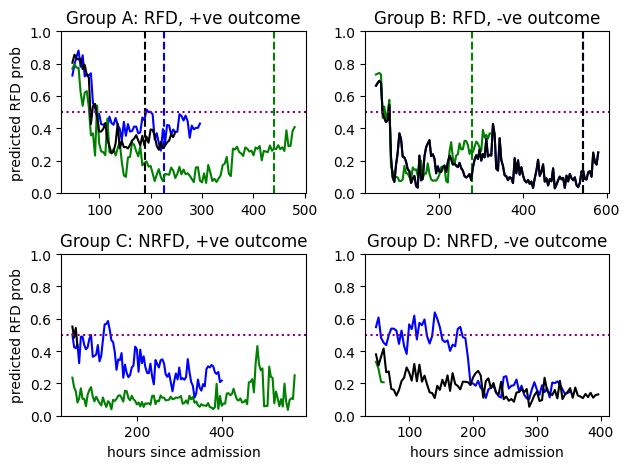

In [711]:
n_rep = 3
groups = {
    'A': 'RFD, +ve outcome', 
    'B': 'RFD, -ve outcome', 
    'C': 'NRFD, +ve outcome',
    'D': 'NRFD, -ve outcome'
}
colours = ['b', 'g', 'k', 'm', 'c']

for gi, g in enumerate(groups.keys()):
    plt.subplot(2,2,gi+1)
    plt.title(f"Group {g}: {groups[g]}")
    
    for r in range(n_rep):
        example_encounter=[]
        while len(example_encounter)==0:
            _eid, example_encounter = get_example_ecounter(g)
        # example_predictions = nclf.predict_proba(example_encounter[nrf_features])[:,1]
        example_predictions = example_encounter.prediction

        plt.plot(
            # scaler.inverse_transform(example_encounter[all_features])[:,all_features.index('hours_since_admission')],
            [48+(i*4) for i in range(len(example_predictions))],
            example_predictions,
            label=_eid,
            c=colours[r]
        )
        if g in ['A', 'B']:
            rfd_datetime_hours = (final_cohort[final_cohort.encounterId==_eid].iloc[0].rfd_datetime - final_cohort[final_cohort.encounterId==_eid].iloc[0].admitStoreDateTime).total_seconds() / 60**2
            plt.axvline(rfd_datetime_hours, color=colours[r], linestyle='--')
    plt.ylim([0,1])
    plt.axhline(0.5, linestyle=':', color='purple')
    # plt.legend()
    
    if gi >1:
        plt.xlabel('hours since admission')
    if gi in [0,2]:
        plt.ylabel('predicted RFD prob')
plt.tight_layout()

In [335]:
a_eid = final_cohort[(~final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==1)].encounterId.unique()
b_eid = final_cohort[(~final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==0)].encounterId.unique()
c_eid = final_cohort[(final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==1)].encounterId.unique()
d_eid = final_cohort[(final_cohort['Declared clinically ready for discharge'].isna()) * (final_cohort.outcome==0)].encounterId.unique()

In [336]:
def get_group(_eid):
    if _eid in a_eid and _eid in hf_test.eid:
        return 'A'
    elif _eid in b_eid and _eid in hf_test.eid:
        return 'B'
    elif _eid in c_eid:
        return 'C'
    elif _eid in d_eid:
        return 'D'
    else:
        return 'E'

In [337]:
alpha = 0.5

In [338]:
# all_high_freq_samples = all_high_freq_samples.copy()

In [339]:
all_high_freq_samples.loc[:,'predicted_label'] = all_high_freq_samples['prediction'] >= alpha

In [340]:
all_high_freq_samples['group'] = [
    get_group(e) for e in all_high_freq_samples.eid
]

In [341]:
import numpy as np

In [712]:
all_high_freq_samples.groupby(['eid', 'predicted_label']).min()[['hours_since_admission', 'group']].reset_index().groupby(['group', 'predicted_label']).agg(['mean', 'std'])

eid              hours_since_admission  \
                               mean          std                  mean   
group predicted_label                                                    
A     False            19065.677291  9075.027477             57.760956   
      True             17436.323410  9080.016808             69.055480   
B     False            20365.690476  9102.844788             56.984127   
      True             18413.929577  9054.963508             80.366197   
C     False            34841.461538    72.808671             50.153846   
      True             34863.800000    55.445268            104.800000   
D     False            17669.018750  9518.618680             49.865000   
      True             18013.526946  9931.856188             73.916168   
E     False            17584.101033  9506.753789             59.797933   
      True             16471.328929  9192.296399             69.357556   

                                                           
                              std        mean         std  
group predicted_label                                      
A     False             17.594871   57.760956   17.594871  
      True              86.299352   69.055480   86.299352  
B     False             14.334844   56.984127   14.334844  
      True             139.662739   80.366197  139.662739  
C     False              5.565461   50.153846    5.565461  
      True              65.937344  104.800000   65.937344  
D     False              7.031613   49.865000    7.031613  
      True             127.830338   73.916168  127.830338  
E     False             21.315300   59.797933   21.315300  
      True              88.686562   69.357556   88.686562

In [713]:
temp = pd.DataFrame()
for c in ['eid', 'predicted_label', 'hours_since_admission', 'group']:
    if c == 'hours_since_admission':
        temp[c] = all_high_freq_samples[c].iloc[:,0]
    else:
        temp[c] = all_high_freq_samples[c]
        

#### TODO: divide the following to encounter/stay length to get a fraction:

In [714]:
temp.groupby('eid').count().rename(columns={'group':'los'})

,predicted_label,hours_since_admission,los
eid,,,
1583,525,525,525
1924,183,183,183
1946,140,140,140
1972,215,215,215
2050,218,218,218
...,...,...,...
34908,3,3,3
34909,69,69,69
34911,4,4,4


In [716]:
_t =temp.groupby(['eid', 'predicted_label']).agg({'hours_since_admission': 'count', 'group':'min'}).reset_index().merge(#.groupby(['group', 'predicted_label']).agg(['mean', 'std'])
    temp.groupby('eid').count().rename(columns={'group':'los'}).reset_index()[['eid', 'los']],
    on='eid', how='left'
)
_t['rate'] = _t['hours_since_admission'] / _t['los']

In [721]:
_t.reset_index().groupby(['group', 'predicted_label']).agg(['mean', 'std'])

index                        eid               \
                              mean          std          mean          std   
group predicted_label                                                        
A     False            4849.749004  2448.267554  19065.677291  9075.027477   
      True             4417.227334  2461.829168  17436.323410  9080.016808   
B     False            5200.809524  2438.296870  20365.690476  9102.844788   
      True             4679.654930  2447.720790  18413.929577  9054.963508   
C     False            8732.076923     7.387620  34841.461538    72.808671   
      True             8734.200000     6.069962  34863.800000    55.445268   
D     False            4464.342500  2558.492521  17669.018750  9518.618680   
      True             4539.071856  2659.572048  18013.526946  9931.856188   
E     False            4442.614619  2556.132713  17584.101033  9506.753789   
      True             4149.604184  2480.049543  16471.328929  9192.296399   

                      hours_since_admission                    los  \
                                       mean         std       mean   
group predicted_label                                                
A     False                       50.119522  121.311519  57.503984   
      True                         9.033829    7.833995  28.832206   
B     False                       63.777778  131.361479  68.500000   
      True                         7.309859    7.188627  37.528169   
C     False                       53.000000   43.418506  58.538462   
      True                         8.400000    5.440588  48.100000   
D     False                       37.521250   56.860583  38.793750   
      True                         6.359281   11.634609  66.341317   
E     False                       43.651741   76.807208  51.494834   
      True                         9.315992    8.962834  27.407377   

                                       rate            
                              std      mean       std  
group predicted_label                                  
A     False            120.312679  0.689384  0.316659  
      True              78.221709  0.681907  0.373655  
B     False            131.056980  0.769864  0.273362  
      True             107.734484  0.584487  0.390520  
C     False             44.003059  0.823892  0.257601  
      True              39.419256  0.428940  0.388670  
D     False             58.290208  0.961883  0.124464  
      True              88.858611  0.266427  0.307395  
E     False             75.490908  0.666439  0.324632  
      True              52.738020  0.679492  0.365653

In [345]:
final_cohort['rfd_hours'] = [
    t.total_seconds() / 60**2 for t in (final_cohort['rfd_datetime'] - final_cohort['admitStoreDateTime'])
]

In [346]:
# final_cohort.fillna({'rfd_hours':'dischargeStoreDateTime'}, inplace=True)
# final_cohort.fillna({'rfd_hours':lambda x: (x.dischargeStoreDateTime - x.admitStoreDatetime).total_seconds() / 60**2}, inplace=True)
filled_rfdh = []
for ri, row in final_cohort.iterrows():
    filled_rfdh.append(
        row.rfd_hours
        if not pd.isna(row.rfd_hours)
        else (row.dischargeStoreDateTime - row.admitStoreDateTime).total_seconds() / 60**2
    )
final_cohort.loc[:, 'rfd_hours'] = filled_rfdh

In [347]:
final_cohort['rfd_hours'] = pd.to_numeric(final_cohort['rfd_hours'])

In [348]:
# all_high_freq_samples.drop(columns=[c for c in all_high_freq_samples.columns if 'rfd_hours' in c], inplace=True)

In [349]:
all_high_freq_samples = all_high_freq_samples.merge(
    final_cohort[['encounterId', 'rfd_hours']],
    how='left',
    left_on='eid',
    right_on='encounterId'
)

In [350]:
all_high_freq_samples.loc[:,'hours_before_discharge'] = all_high_freq_samples['rfd_hours'] - all_high_freq_samples.iloc[:,1]

In [358]:
def q25(x):
    return x.quantile(0.25)

def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

In [726]:
all_high_freq_samples[all_high_freq_samples.iloc[:,1]>=72].groupby(['eid', 'predicted_label']).max()[['hours_before_discharge', 'group']].reset_index().groupby(['group', 'predicted_label']).agg(['median', iqr, 'mean', 'std'])
# all_high_freq_samples.groupby(['eid', 'predicted_label']).max()[['hours_before_discharge', 'group']].reset_index().groupby(['group', 'predicted_label']).agg(['median', iqr, 'mean', 'std'])

eid                                        \
                        median       iqr          mean           std   
group predicted_label                                                  
A     False            20905.5  15524.00  19080.137778   9005.950335   
      True             19795.0  16317.00  17946.361493   9170.170374   
B     False            21515.0  14276.00  20752.000000   8962.599019   
      True             19833.5  15242.00  18240.255814   9181.752091   
C     False            34824.0     94.00  34821.700000     71.806917   
      True             34863.5    100.50  34852.375000     56.621393   
D     False            17870.5  16592.25  17930.125382   9441.900707   
      True             19007.0  18584.00  19222.684783  10002.690782   
E     False            16791.0  17152.00  17573.764554   9593.902299   
      True             15730.0  16226.00  16926.543608   9432.380607   

                      hours_before_discharge                          \
                                      median         iqr        mean   
group predicted_label                                                  
A     False                        85.981104  191.851557  167.095576   
      True                         22.075979   63.232269   51.128773   
B     False                       115.520131  220.904819  248.208568   
      True                         37.021491  122.068152  120.744037   
C     False                       307.781618  200.601360  284.234376   
      True                        140.013257  226.765255  157.412971   
D     False                        73.544073  164.183025  155.616821   
      True                        144.262496  268.261803  278.055526   
E     False                        81.746804  177.001834  163.352405   
      True                         23.202383   67.258542   54.192864   

                                   
                              std  
group predicted_label              
A     False            230.442819  
      True             105.194288  
B     False            527.606132  
      True             393.798046  
C     False            152.425249  
      True             129.267053  
D     False            223.148906  
      True             345.207113  
E     False            242.903654  
      True             125.681407

In [356]:
all_high_freq_samples.groupby(['eid', 'predicted_label']).min()[['hours_since_admission', 'group']].reset_index().groupby(['group', 'predicted_label']).agg(['median', q25, q75])

eid                     hours_since_admission  \
                        median       q25       q75                median   
group predicted_label                                                      
A     False            20884.0  10728.25  26692.50                  48.0   
      True             19045.0   8634.00  25088.00                  48.0   
B     False            21493.5  13320.00  27737.50                  48.0   
      True             20034.5  10003.50  25219.25                  48.0   
C     False            34850.0  34789.00  34909.00                  48.0   
      True             34889.5  34813.50  34908.75                  80.0   
D     False            17186.0   9512.50  26372.00                  48.0   
      True             18226.0   9282.00  27238.50                  48.0   
E     False            16820.0   9426.00  26270.00                  48.0   
      True             15418.0   8912.00  22653.00                  48.0   

                                                        
                        q25    q75 median   q25    q75  
group predicted_label                                   
A     False            48.0   60.0   48.0  48.0   60.0  
      True             48.0   48.0   48.0  48.0   48.0  
B     False            48.0   60.0   48.0  48.0   60.0  
      True             48.0   48.0   48.0  48.0   48.0  
C     False            48.0   48.0   48.0  48.0   48.0  
      True             48.0  158.0   80.0  48.0  158.0  
D     False            48.0   48.0   48.0  48.0   48.0  
      True             48.0   56.0   48.0  48.0   56.0  
E     False            48.0   64.0   48.0  48.0   64.0  
      True             48.0   48.0   48.0  48.0   48.0

#### Instability:

In [378]:
records = []
for e in final_cohort.encounterId:
    _series = all_high_freq_samples[all_high_freq_samples.eid==e].predicted_label
    if len(_series) > 1:
        l = _series.iloc[0]
        diff_count = 0
        for nl in _series.iloc[1:]:
            if nl!=l:
                diff_count += 1
            l = nl
        sigma = diff_count / (len(_series) - 1)
    else:
        diff_count = 0
        sigma = 0
        
    records.append(
        {
            'eid': e,
            'diff_count': diff_count,
            'los': len(_series),
            'sigma': sigma
        }
    )
instability_df = pd.DataFrame.from_records(records)

In [733]:
all_high_freq_samples.groupby('eid').min().reset_index()[['eid','group']].merge(instability_df, on='eid').groupby('group').agg(['mean', 'std'])

eid              diff_count                  los              \
               mean          std       mean       std       mean         std   
group                                                                          
A      17979.778813  9059.891807   1.939464  3.105535  43.529686  127.347889   
B      19308.648352  9005.270674   1.780220  3.099821  54.098901  118.694003   
C      34849.600000    70.777115   3.600000  4.516636  51.533333   44.751483   
D      17693.346341  9543.524603   0.784146  2.375802  40.091463   62.664798   
E      16712.175083  9212.024324   2.067485  3.348836  37.039877   74.090677   

          sigma            
           mean       std  
group                      
A      0.076622  0.116795  
B      0.083479  0.135079  
C      0.132422  0.256252  
D      0.026309  0.090756  
E      0.087278  0.135371

In [727]:
instability_df

,eid,diff_count,los,sigma
0,1583,2,525,0.003817
1,1924,2,183,0.010989
2,1946,4,140,0.028777
3,1972,0,215,0.000000
4,2050,0,218,0.000000
...,...,...,...,...
8096,34909,12,69,0.176471
8097,34911,3,4,1.000000
8098,34912,0,0,0.000000
8099,34917,2,8,0.285714


(array([6.358e+03, 7.670e+02, 5.530e+02, 2.280e+02, 8.600e+01, 7.400e+01,
        1.200e+01, 3.000e+00, 4.000e+00, 1.600e+01]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

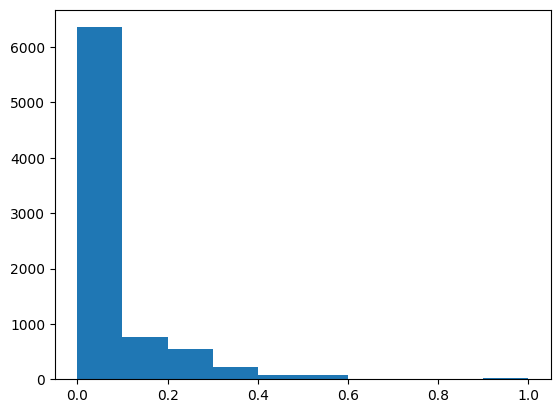

In [380]:
plt.hist(instability_df.sigma)

In [376]:
(all_high_freq_samples[all_high_freq_samples.eid==1583].predicted_label==True).sum()

np.int64(1)

In [614]:
final_cohort = pd.read_json('..\data\processed\linked_cohort_181024.json', convert_dates=['admitStoreDateTime', 'dischargeStoreDateTime', 'rfd_datetime'])

In [615]:
import os
os.chdir('../streamlit/')
from utilities import LocalDatabaseWrapper
os.chdir('../development')

In [616]:
project_name = "smartt_bmj_open_plus"
database_path = Path("../data")

In [617]:
local_db = LocalDatabaseWrapper(
            database_path / f"{project_name}.db"
        )

In [618]:
final_mapping = local_db.query_pd(
    "select * from final_mapping;"
    
)

In [619]:
schema = local_db.query_pd(
    "select * from schema;"
)

In [620]:
demographic_variables = schema[schema['Time Series']==0]

In [621]:
demographic_variables_list = ['Age at admission', 'DOB', 'Gender', 'BMI', 'Weight', 'Ethnicity', 'Postcode', 'Admit source']

In [622]:
records = []
for ei, EID in enumerate(final_cohort.encounterId):
    
    df = local_db.query_pd(
        f"select * from full_extract where encounterId = {EID};"
    )
    
    df = df.merge(final_mapping, on=['interventionId', 'attributeId'])
    
    record = {'encounterId': EID}
    for v in demographic_variables_list:
        value = df[(df.schemaVariable==v)*(~df.verboseForm.isna())]
        if len(value) > 0:
            value = value.iloc[0]['verboseForm']
        else:
            value = None
        record[v] = value
    records.append(record)

demographic_df = pd.DataFrame.from_records(records)

In [639]:
merged_final_cohort = final_cohort.copy()

In [640]:
for col in demographic_df.columns:
    merged_final_cohort[col] = demographic_df[col]

In [641]:
len(merged_final_cohort)

8101

In [642]:
merged_final_cohort['DOB'] = pd.to_datetime(merged_final_cohort['DOB'], dayfirst=True)

In [643]:
merged_final_cohort['Age'] = [t.total_seconds() / (365 * 24 * 60**2)  if not pd.isna(t) else t for t in merged_final_cohort['admitStoreDateTime'] - merged_final_cohort['DOB']]

In [645]:
train, test = train_test_split(merged_final_cohort[merged_final_cohort['Declared clinically ready for discharge']=='Yes'], test_size=0.2, random_state=42)

In [646]:
len(test)

1050

In [647]:
len(final_cohort[final_cohort['Declared clinically ready for discharge']!='Yes'])

2851

In [648]:
len(final_cohort[final_cohort['Declared clinically ready for discharge']!='Yes']) + len(test)+ len(train)

8101

In [690]:
temp = merged_final_cohort[merged_final_cohort['Declared clinically ready for discharge']!='Yes']
# temp = test

In [691]:
100* temp[['in_hospital_mortality', 'readmission',
       'readmission_this_stay', 'outcome']].sum()/ len(temp)

in_hospital_mortality    49.666784
readmission               2.841108
readmission_this_stay     6.664328
outcome                  44.300246
dtype: float64

In [664]:
print(
    f"median : {np.median(pd.Series([t.total_seconds() / (24 * 60**2) for t in temp['dischargeStoreDateTime'] - temp['admitStoreDateTime']])):.1f}",
    f"iqr : {iqr(pd.Series([t.total_seconds() / (24 * 60**2) for t in temp['dischargeStoreDateTime'] - temp['admitStoreDateTime']])):.1f}"
)

median : 3.7 iqr : 4.1


In [672]:
def print_demographics(df):
    df['BMI'] = pd.to_numeric(df['BMI'])
    print(f"Age: {df['Age'].median():.3f}({iqr(df['Age']):.3f})")
    print(f"BMI: {df['BMI'].mean():.3f}({df['BMI'].std():.3f})")
    # print(df.groupby('Ethnicity').Age.count())
    # print('......')
    # print(df.groupby('Gender').Age.count())
    print(df.groupby('Gender').Age.count() / df.groupby('Gender').Age.count().sum())

In [677]:
print_demographics(merged_final_cohort[merged_final_cohort['Declared clinically ready for discharge']!='Yes'])

Age: 61.392(22.715)
BMI: 27.577(7.289)
Gender
Female     0.407367
Male       0.588621
Unknown    0.004012
Name: Age, dtype: float64


C:\Users\mcwilliamschr\AppData\Local\Temp\13\ipykernel_31672\206798002.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['BMI'] = pd.to_numeric(df['BMI'])


In [501]:
100*40/(3234+4824+40)

0.49394912324030626

In [495]:
len(test) 

1680

In [496]:
.2*8050

1610.0

In [488]:
final_cohort[['Age'] + [d for d in demographic_variables_list if 'Age' not in d]].dtypes

Age                     object
DOB             datetime64[ns]
Gender                  object
BMI                     object
Weight                  object
Ethnicity               object
Postcode                object
Admit source            object
dtype: object

#### This is like the example given in the documentation, but seems wrong to me and is very slow!:

In [ ]:
pipe = Pipeline([
    ('sfs', sfs1),
    ('rf', rfc2)
])

In [ ]:
param_grid ={
    'sfs__k_features': [10, 15, 20, 25, 30, 35],
    'sfs__estimator__max_depth': [3, 5, 10, None],
    'sfs__estimator__n_estimators': [10, 100, 200],
    'sfs__estimator__max_features': [3, 5, 7, 'sqrt', None],
    'sfs__estimator__min_samples_leaf': [1, 2, 3],
    'sfs__estimator__min_samples_split': [2, 3, 5],
    'rf__max_depth': [3, 5, 10, None],
    'rf__n_estimators': [10, 100, 200, 500],
    'rf__max_features': [3, 5, 7, 'sqrt', None],
    'rf__min_samples_leaf': [1, 2, 3],
    'rf__min_samples_split': [2, 3, 5],
}

In [ ]:
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

In [ ]:
gs.fit(
    train[original_features + new_features],
    train['label'],
)

In [ ]:
gs.get_params()

In [ ]:
lr_features = all_features

fpr, tpr, thresholds = roc_curve(
    test['label'],
    gs.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    gs.predict_proba(test[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_test (auc={auc:.3f})")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    gs.predict_proba(train[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    gs.predict_proba(train[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_train (auc={auc:.3f})")

## RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    clf.predict_proba(test[original_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    clf.predict_proba(test[original_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_test (auc={auc:.3f}")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    clf.predict_proba(train[original_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    clf.predict_proba(train[original_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_train (auc={auc:.3f})")


## New RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    nclf.predict_proba(test[original_features + new_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    nclf.predict_proba(test[original_features + new_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_test (auc={auc:.3f})")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    nclf.predict_proba(train[original_features + new_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    nclf.predict_proba(train[original_features + new_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_train (auc={auc:.3f})")


plt.legend();


#### We now test the classifiers on the cohort subset that were not declared RFD.

There are two groups:
* those with positive outcomes, who are assigned label 1 at the end of their stay, but who may have been ready earlier,
* those with negative outcomes, who are assigned label 0 throughout. Adn we therefore hope for a low false positive rate (although they are not reflected in training).

We should also look at the NRFD instances for patients who were declared fit for discharge but had a negative outcoem - these should be harder cases for the classifier.